In [106]:
import json
results_files = [
    '../output/2-agents_domain-Matrix-IPD_drift-identity_DRIVE-TD-UNSTABLE-COMMUNICATION_2026-04-12-12-57-53/results.json',
    '../output/2-agents_domain-Matrix-IPD_drift-identity_DRIVE-TD_2026-04-12-12-57-40/results.json'
 ]

json_data = []
for results_file in results_files:
    with open(results_file) as f:
        json_data.append(json.load(f))

In [113]:
import numpy as np

cooperations_per_epoch = np.array([d["domain_values"] for d in json_data])[..., 1] / 150

In [114]:
cooperations_per_epoch.shape

(2, 4000)

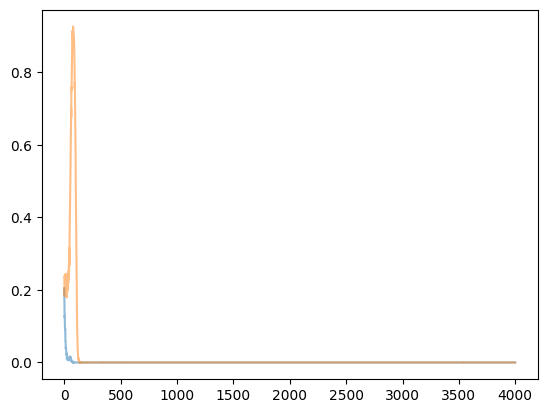

In [115]:
from matplotlib import pyplot as plt

for f, coop in zip(results_files, cooperations_per_epoch):
    plt.plot(list(range(len(coop))), coop, label=f, alpha=0.5)

In [91]:
cooperations = np.apply_along_axis(func1d=lambda a: 1 if a.sum() == 0 else 0, arr=joint_actions_history, axis=-1)

In [92]:
mean_cooperation = (cooperations.sum(axis=-1) / cooperations.shape[-1]).mean(axis=(-1))
std_cooperation = cooperations.std(axis=(-2, -1))

In [93]:
mean_cooperation.shape

(2, 4000)

Text(0, 0.5, 'Cooperation Rate')

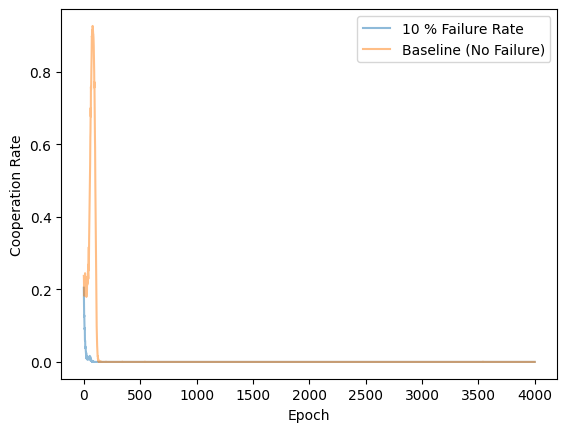

In [94]:
from matplotlib import pyplot as plt

labels = ['10 % Failure Rate', 'Baseline (No Failure)']
for m, s, l in zip(mean_cooperation, std_cooperation, labels):
    plt.plot(list(range(len(m))), m, label=l, alpha=0.5)

plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Cooperation Rate')

In [95]:
single_defections = np.apply_along_axis(func1d=lambda a: 1 if a.sum() == 1 else 0, arr=joint_actions_history, axis=-1)

mean_single_defection = (single_defections.sum(axis=-1) / single_defections.shape[-1]).mean(axis=(-1))

In [96]:
double_defections = np.apply_along_axis(func1d=lambda a: 1 if a.sum() == 2 else 0, arr=joint_actions_history, axis=-1)

mean_double_defection = (double_defections.sum(axis=-1) / double_defections.shape[-1]).mean(axis=(-1))

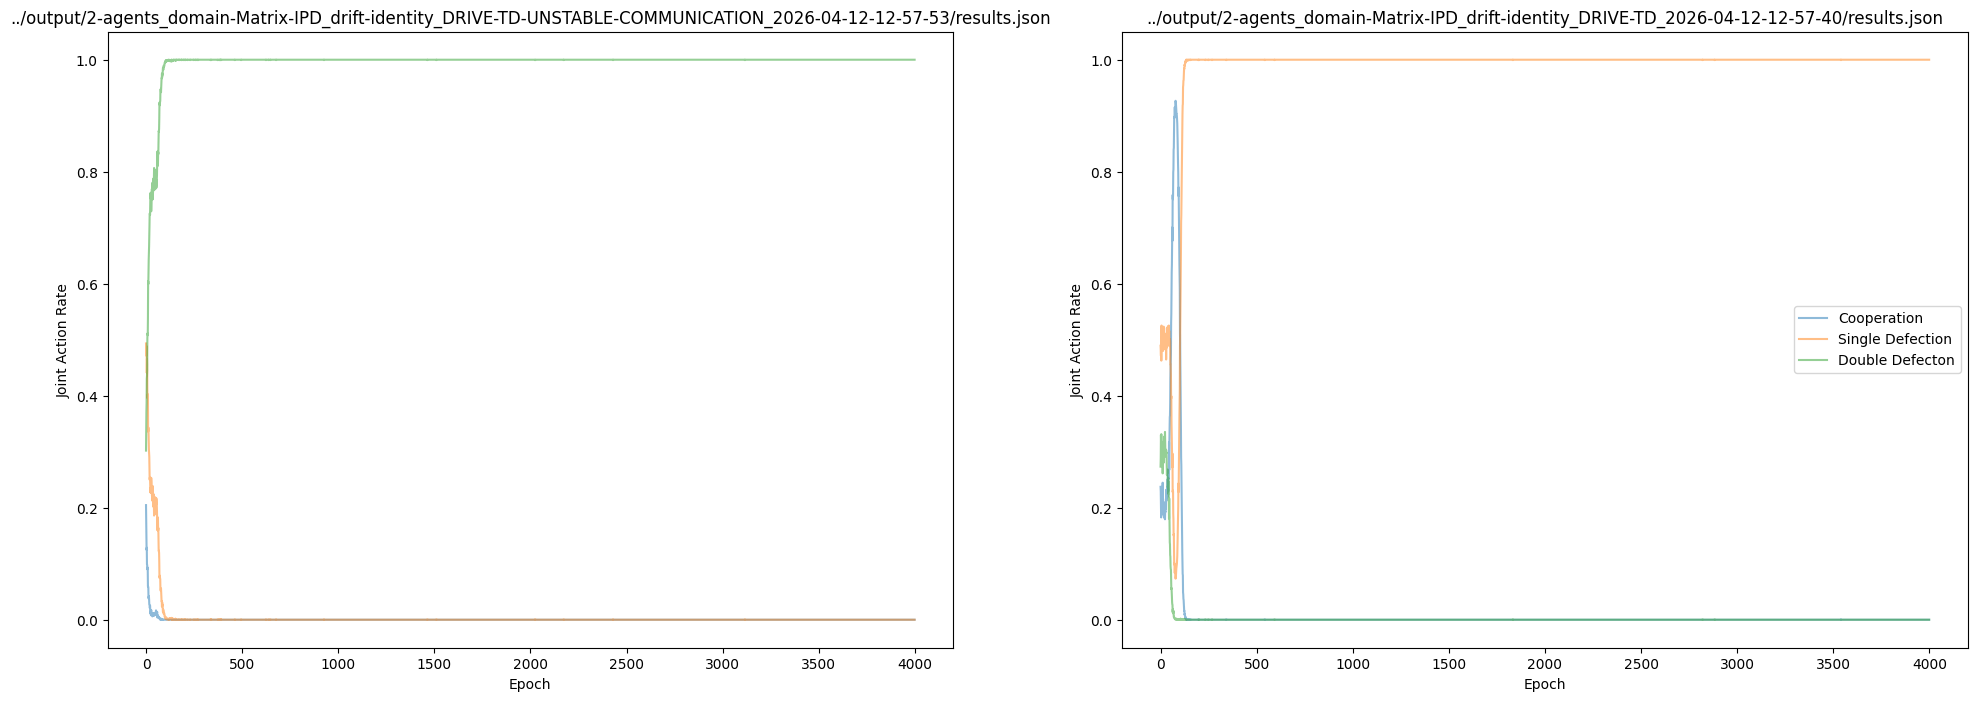

In [105]:
fig, axs = plt.subplots(len(results_files) // 2, 2, figsize=(24, len(results_files) * 4))

for ax, f, m_c, m_s_d, m_d_d in zip(axs, results_files, mean_cooperation, mean_single_defection, mean_double_defection):
    ax.plot(list(range(len(m_c))), m_c, label='Cooperation', alpha=0.5)
    ax.plot(list(range(len(m_s_d))), m_s_d, label='Single Defection', alpha=0.5)
    ax.plot(list(range(len(m_d_d))), m_d_d, label='Double Defecton', alpha=0.5)
    ax.set_title(f)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Joint Action Rate')
plt.legend()